# Generation Demo

Generate samples from a saved `ConditionalNodeFieldGraphGenerator`.

- inspect saved checkpoints
- load one model
- sample with and without feasibility filtering


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import os
import random

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

from conditional_node_field_graph_generator.notebooks import configure_notebook, download_zinc_dataset
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.input_sources import iter_selected_source_graphs
from conditional_node_field_graph_generator.extensions.demo import plot_networkx_graphs
from conditional_node_field_graph_generator.extensions.synthetic import generate_artificial_dataset
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


PyTorch version: 2.2.2
CUDA available: False


In [2]:
import random
import sys
import time
from types import MethodType

import networkx as nx
from sklearn.linear_model import SGDClassifier, SGDRegressor
from nsppk import NSPPK

from abstractgraph.operators import (
    add,
    combination,
    compose,
    connected_component,
    cycle,
    edge,
    filter_by_edge_label,
    merge,
    neighborhood,
    tree,
    unlabel,
)
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_ml.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
)

EDGE_GENERATIVE_SRC_CANDIDATES = [
    REPO_ROOT.parent / 'abstractgraph-ecosystem' / 'repos' / 'abstractgraph-generative' / 'src',
    REPO_ROOT.parent.parent / 'abstractgraph-ecosystem' / 'repos' / 'abstractgraph-generative' / 'src',
]
EDGE_GENERATIVE_SRC = next(
    (path for path in EDGE_GENERATIVE_SRC_CANDIDATES if path.exists()),
    EDGE_GENERATIVE_SRC_CANDIDATES[0],
)
if not EDGE_GENERATIVE_SRC.exists():
    searched = '\n'.join(f'  - {path}' for path in EDGE_GENERATIVE_SRC_CANDIDATES)
    raise RuntimeError(f'abstractgraph-generative checkout not found. Searched:\n{searched}')
if str(EDGE_GENERATIVE_SRC) not in sys.path:
    sys.path.insert(0, str(EDGE_GENERATIVE_SRC))

from abstractgraph_generative.edge_generator import EdgeGenerator

def _find_early_stop_in_beam_any_phase(
    self,
    beam,
    *,
    scored,
    n_edges: int,
    target,
    target_lambda: float,
    fallback_index: int,
    graph_index: int,
    total_phases: int,
    start_time: float,
    verbose: bool,
):
    if not self.early_stop_if_final_feasible or not beam:
        return None

    current_states = self._score_current_beam_states_for_early_stop(
        beam,
        target=target,
        target_lambda=target_lambda,
        fallback_index=fallback_index,
    )
    if not current_states:
        return None

    best_current = current_states[0]
    best_expansion_score = None
    if scored['feasible_candidates']:
        best_expansion_score = scored['feasible_candidates'][0].get(
            'selection_score',
            scored['feasible_candidates'][0]['score'],
        )

    current_score = best_current.get('selection_score', best_current['score'])
    if best_expansion_score is not None and current_score < best_expansion_score:
        return None

    path = self._reconstruct_path(best_current)
    if verbose:
        elapsed_str = self._format_minutes_seconds(time.perf_counter() - start_time)
        current_edges = best_current['graph'].number_of_edges()
        edge_shortfall = max(0, n_edges - current_edges)
        print(
            f'[graph {graph_index}] early_stop fallback={fallback_index + 2}/{total_phases} '
            f"depth={best_current['depth']} max_depth={self.max_depth_} "
            f'edges={current_edges} edge_shortfall={edge_shortfall} remaining_edges=0 '
            f'tried={self.n_tried_} elapsed={elapsed_str} eta=0m 0.0s'
        )
        print(
            f'[graph {graph_index}] early_stop_selection_score='
            f"{current_score:.3f} best_expansion_selection_score="
            f'{self._format_optional_score(best_expansion_score)}'
        )
    return path



def _random_edge_attributes_from_graph(graph, rng):
    edge_data = [dict(attrs) for _, _, attrs in graph.edges(data=True)]
    if not edge_data:
        return {}
    return dict(rng.choice(edge_data))


def pad_graph_to_neighbor_edge_count(graph, neighbor_graphs, rng):
    same_node_neighbors = [
        neighbor
        for neighbor in neighbor_graphs
        if neighbor.number_of_nodes() == graph.number_of_nodes()
    ]
    if not same_node_neighbors:
        return graph.copy(), graph.number_of_edges(), None

    current_edge_count = graph.number_of_edges()
    eligible_neighbors = [
        neighbor
        for neighbor in same_node_neighbors
        if neighbor.number_of_edges() >= current_edge_count
    ]
    if not eligible_neighbors:
        eligible_neighbors = same_node_neighbors
    target_neighbor = rng.choice(eligible_neighbors)
    target_edge_count = max(current_edge_count, target_neighbor.number_of_edges())

    padded_graph = graph.copy()
    max_edge_count = padded_graph.number_of_nodes() * (padded_graph.number_of_nodes() - 1) // 2
    target_edge_count = min(target_edge_count, max_edge_count)
    if target_edge_count <= current_edge_count:
        return padded_graph, current_edge_count, target_neighbor

    missing_edges = list(nx.non_edges(padded_graph))
    rng.shuffle(missing_edges)
    while padded_graph.number_of_edges() < target_edge_count and missing_edges:
        u, v = missing_edges.pop()
        padded_graph.add_edge(u, v, **_random_edge_attributes_from_graph(target_neighbor, rng))

    return padded_graph, padded_graph.number_of_edges(), target_neighbor


def repair_candidate_graphs(
    candidate_graphs,
    *,
    graph_generator,
    repair_graph_dataset,
    random_seed,
    store_per_size=256,
    n_neighbors=12,
    draw_graphs_fn=None,
    show_summary=True,
    edge_label_values=None,
):
    if graph_generator.feasibility_estimator is None:
        raise RuntimeError('EdgeGenerator repair requires a fitted feasibility estimator.')

    candidate_graphs = list(candidate_graphs)
    if not candidate_graphs:
        print('No candidate graphs to repair.')
        return {
            'repaired_graphs': [],
            'valid_repaired_graphs': [],
            'sample_feasible': np.asarray([], dtype=bool),
            'padded_candidate_graphs': [],
            'repair_target_edge_counts': [],
            'repaired_feasible': None,
            'stored_counts': {},
            'edge_repair_generator': None,
            'edge_repair_graphs': [],
        }
    rng = random.Random(random_seed)

    sample_node_counts = sorted({graph.number_of_nodes() for graph in candidate_graphs})
    repair_graph_dataset = list(repair_graph_dataset)
    if not repair_graph_dataset:
        raise ValueError('repair_graph_dataset must contain at least one graph.')

    stored_counts = {node_count: 0 for node_count in sample_node_counts}
    edge_repair_graphs = []
    for node_count in sample_node_counts:
        selected_graphs = [
            graph
            for graph in repair_graph_dataset
            if graph.number_of_nodes() == node_count
        ][:store_per_size]
        edge_repair_graphs.extend(selected_graphs)
        stored_counts[node_count] = len(selected_graphs)

    missing_sizes = [node_count for node_count, count in stored_counts.items() if count == 0]
    if missing_sizes:
        available_sizes = sorted({graph.number_of_nodes() for graph in repair_graph_dataset})
        raise RuntimeError(
            f'Could not find repair graphs for node counts: {missing_sizes}. '
            f'Available node counts in repair_graph_dataset: {available_sizes}'
        )

    feasibility_kwargs = dict(
        nbits=19,
        parallel=True,
        backend='loky',
        n_jobs=-1,
    )

    partial_feasibility_estimators = [
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=compose(neighborhood(radius=4), unlabel()),
            **feasibility_kwargs,
        ),
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=neighborhood(radius=1),
            **feasibility_kwargs,
        ),
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=compose(cycle(), unlabel()),
            **feasibility_kwargs,
        ),
    ]
    partial_feasibility_estimator = FeasibilityEstimator(partial_feasibility_estimators)

    final_feasibility_estimators = [
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=compose(neighborhood(radius=4), unlabel()),
            **feasibility_kwargs,
        ),
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=neighborhood(radius=1),
            **feasibility_kwargs,
        ),
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=compose(cycle(), unlabel()),
            **feasibility_kwargs,
        ),
    ]
    if edge_label_values:
        final_feasibility_estimators.append(
            FeasibilityEstimatorFeatureCannotExist(
                decomposition_function=compose(
                    connected_component(),
                    unlabel(),
                    merge(use_edges=True),
                    filter_by_edge_label(must_have_one_of=list(edge_label_values)),
                    edge(),
                ),
                **feasibility_kwargs,
            )
        )
    final_feasibility_estimator = FeasibilityEstimator(final_feasibility_estimators)

    use_sparse_linear_mode = True
    vectorizer_kwargs = dict(
        radius=1,
        distance=4,
        connector=1,
        nbits=14,
        parallel=True,
    )

    graph_transformer = NSPPK(**vectorizer_kwargs, dense=not use_sparse_linear_mode)
    graph_estimator_model = SGDClassifier(
        loss='log_loss',
        alpha=1e-4,
        max_iter=1000,
        tol=1e-3,
        random_state=random_seed,
        class_weight='balanced',
    )
    target_estimator_model = SGDRegressor(
        loss='epsilon_insensitive',
        alpha=1e-4,
        max_iter=1000,
        tol=1e-3,
        random_state=random_seed,
    )
    edge_risk_estimator_model = SGDRegressor(
        loss='epsilon_insensitive',
        alpha=1e-4,
        max_iter=1000,
        tol=1e-3,
        random_state=random_seed,
    )

    graph_estimator = GraphEstimator(
        transformer=graph_transformer,
        estimator=graph_estimator_model,
    )
    target_estimator = None
    edge_risk_estimator = GraphEstimator(
        transformer=NSPPK(**vectorizer_kwargs, dense=not use_sparse_linear_mode),
        estimator=edge_risk_estimator_model,
    )

    edge_repair_generator = EdgeGenerator(
        partial_feasibility_estimator=partial_feasibility_estimator,
        final_feasibility_estimator=final_feasibility_estimator,
        graph_estimator=graph_estimator,
        target_estimator=target_estimator,
        edge_risk_estimator=edge_risk_estimator,
        target_estimator_mode='regression',
        decomposition_function=add(cycle(), tree()),
        enforce_diversity=False,
        n_negative_per_positive=5,
        n_replicates=5,
        beam_size=2,
        max_restarts=4,
        fit_n_jobs=-1,
        fit_backend='loky',
        edge_risk_lambda=0.25,
        verbose=True,
        seed=random_seed,
        early_stop_if_final_feasible=True,
        require_single_connected_component=True,
    )
    edge_repair_generator._find_early_stop_in_beam = MethodType(
        _find_early_stop_in_beam_any_phase,
        edge_repair_generator,
    )
    edge_repair_generator.store(edge_repair_graphs)

    if draw_graphs_fn is None:
        raise ValueError('draw_graphs_fn must be provided so repair rendering stays dataset-specific.')

    sample_feasible = np.asarray(
        graph_generator.feasibility_estimator.predict(candidate_graphs),
        dtype=bool,
    )
    padded_candidate_graphs = []
    repair_target_edge_counts = []
    repaired_graphs = []
    for sample_idx, graph in enumerate(candidate_graphs):
        repair_neighbor_count = min(n_neighbors, len(edge_repair_graphs))
        repair_context = edge_repair_generator._prepare_repair_training_context(
            graph,
            n_neighbors=repair_neighbor_count,
        )
        padded_graph, padded_edge_count, target_neighbor = pad_graph_to_neighbor_edge_count(
            graph,
            repair_context['fit_graphs'],
            rng,
        )
        padded_candidate_graphs.append(padded_graph)
        repair_target_edge_counts.append(padded_edge_count)
        repaired_graph = edge_repair_generator.repair(
            padded_graph,
            n_neighbors=repair_neighbor_count,
            draw_graphs_fn=draw_graphs_fn,
            return_path=False,
        )
        repaired_graphs.append(repaired_graph)
        neighbor_edges = None if target_neighbor is None else target_neighbor.number_of_edges()
        print(
            f'sample {sample_idx}: nodes={graph.number_of_nodes()} edges={graph.number_of_edges()} '
            f'padded_edges={padded_edge_count} neighbor_edges={neighbor_edges} '
            f'feasible_before={bool(sample_feasible[sample_idx])} repaired={repaired_graph is not None}'
        )

    valid_repaired_graphs = [graph for graph in repaired_graphs if graph is not None]
    repaired_feasible = None
    if valid_repaired_graphs:
        repaired_feasible = np.asarray(
            graph_generator.feasibility_estimator.predict(valid_repaired_graphs),
            dtype=bool,
        )

    if show_summary:
        if valid_repaired_graphs:
            print('stored_counts =', stored_counts)
            print('repaired_feasible =', repaired_feasible.tolist())
            draw_graphs_fn(
                candidate_graphs,
                n=len(candidate_graphs),
                title='Raw samples before EdgeGenerator repair',
            )
            draw_graphs_fn(
                valid_repaired_graphs,
                n=len(valid_repaired_graphs),
                title='Raw samples after EdgeGenerator repair',
            )
        else:
            print('EdgeGenerator repair did not return any repaired samples.')

    return {
        'repaired_graphs': repaired_graphs,
        'valid_repaired_graphs': valid_repaired_graphs,
        'sample_feasible': sample_feasible,
        'padded_candidate_graphs': padded_candidate_graphs,
        'repair_target_edge_counts': repair_target_edge_counts,
        'repaired_feasible': repaired_feasible,
        'stored_counts': stored_counts,
        'edge_repair_generator': edge_repair_generator,
        'edge_repair_graphs': edge_repair_graphs,
    }


In [3]:
#MODEL_FILENAME = 'zinc15-nonstreaming-d64-s0-99-b128-e350.pkl'
#MODEL_FILENAME = 'zinc15-streaming-d64-s0-5-w256-b8-e256.pkl'
#MODEL_FILENAME = 'zinc18-streaming-d64-s0-9-w2049-b128-e256.pkl'
#MODEL_FILENAME = 'zinc20-nonstreaming-d64-s0-99-b128-e350.pkl'
#MODEL_FILENAME = 'artificial-cycle-path-star-n1024-c-3-8-p-3-6-r-2-4-x2-d64-b128-e350.pkl'
#MODEL_FILENAME = 'artificial-cycle-path-star-n10240-c-3-8-p-3-6-r-2-4-x2-d64-b128-e350.pkl'
#MODEL_FILENAME = 'artificial-cycle-path-star-n5000-c6-p4-r0x0-d64-b128-e350.pkl'
#MODEL_FILENAME = 'zinc20-nonstreaming-d192-svd64-s55000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl'
#MODEL_FILENAME = 'zinc-nonstreaming-d256-svd64-sall-b256-lr0-0001-mask0-35-l6-drop0-1-e350.pkl'
MODEL_FILENAME = 'zinc15-nonstreaming-d64-s5000-b64-lr0-0002-mask0-5-e350.pkl'
N_SAMPLES = 1

DECODER_VERBOSE = 1
DECODER_DIRECT_EDGE_PROBABILITY_THRESHOLD = 0.5
DECODER_ENFORCE_CONNECTIVITY = True
DECODER_DEGREE_SLACK_PENALTY = 1e6  # Lower values are probability-first ablations.
DECODER_EDGE_COUNT_SLACK_PENALTY = 2.0
DECODER_WARM_START_MST = True
DECODER_N_JOBS = -1
DECODER_GRAPH_RENDERER = None

USE_FEASIBILITY_FILTERING = True
MAX_FEASIBILITY_ATTEMPTS = 5
FEASIBILITY_CANDIDATES_PER_ATTEMPT = 2
FEASIBILITY_FAILURE_MODE = 'return_partial'
MAX_FEASIBILITY_SECONDS_PER_SAMPLE = 10.0
MAX_DECODE_ATTEMPTS_PER_SAMPLE = 3
FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT = 1
MAX_ORACLE_ITERATIONS = 10
ORACLE_ADD_EDGE_REPAIR_BUDGET = 32
ORACLE_USE_NODE_LABEL_CUTS = True
ORACLE_USE_EDGE_LABEL_CUTS = True
ORACLE_EDGE_LABEL_MIN_CHANGES_PER_VIOLATION = 2
RANDOM_SEED = 7
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

REPAIR_DATASET_SOURCE = 'zinc'  # 'artificial' or 'zinc'
REPAIR_DATASET_SIZE = 512
REPAIR_STORE_PER_SIZE = 256
REPAIR_EDGE_LABEL_VALUES = None  # e.g. ('aromatic',) for molecule-specific edge-label constraints
REPAIR_ARTIFICIAL_CONFIG_FILE = 'artificial-cycle-path-star-n5000-c6-p4-r0x0-na3.yaml'  # or None to regenerate from REPAIR_ARTIFICIAL_CONFIG

REPAIR_ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
REPAIR_ZINC_SIZE = 'zinc15'
REPAIR_ZINC_FILENAME = f'{REPAIR_ZINC_SIZE}.csv'
REPAIR_ZINC_LIMIT = None

ARTIFICIAL_NODE_LABEL_COLORS = {
    0: '#fee2e2',
    1: '#fca5a5',
    2: '#dc2626',
    3: '#dbeafe',
    4: '#93c5fd',
    5: '#2563eb',
    6: '#dcfce7',
    7: '#86efac',
    8: '#16a34a',
}

ARTIFICIAL_GRAPH_PLOT_KWARGS = {
    'node_label_colors': ARTIFICIAL_NODE_LABEL_COLORS,
    'size': 4,
    'show_label': True,
    'cmap': 'tab20',
    'light': 0.4,
    'color_offset': 200,
    'node_size': 300,
    'node_linewidths': 2,
    'edge_width': 2,
}

REPAIR_ARTIFICIAL_PLOT_KWARGS = (
    ARTIFICIAL_GRAPH_PLOT_KWARGS
    if REPAIR_DATASET_SOURCE.lower().strip() == 'artificial'
    else {}
)

REPAIR_ARTIFICIAL_CONFIG = dict(
    cycle_length=(3, 8),
    num_cycles=1,
    path_length=(3, 6),
    num_rays=(2, 4),
    ray_length=2,
    node_alphabet_size=3,
    edge_alphabet_size=2,
    node_alphabet_kind='int',
    edge_alphabet_kind='int',
    component_specific_alphabets=True,
)


In [4]:
list_saved_graph_generators(SAVED_GENERATOR_ROOT)

graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)
graph_generator.graph_decoder.verbose = DECODER_VERBOSE
graph_generator.graph_decoder.direct_edge_probability_threshold = DECODER_DIRECT_EDGE_PROBABILITY_THRESHOLD
graph_generator.graph_decoder.enforce_connectivity = DECODER_ENFORCE_CONNECTIVITY
graph_generator.graph_decoder.degree_slack_penalty = DECODER_DEGREE_SLACK_PENALTY
graph_generator.graph_decoder.edge_count_slack_penalty = DECODER_EDGE_COUNT_SLACK_PENALTY
graph_generator.graph_decoder.warm_start_mst = DECODER_WARM_START_MST
graph_generator.graph_decoder.n_jobs = DECODER_N_JOBS
graph_generator.graph_decoder.diagnostic_graph_renderer = DECODER_GRAPH_RENDERER
graph_generator.use_feasibility_filtering = USE_FEASIBILITY_FILTERING
graph_generator.max_feasibility_attempts = MAX_FEASIBILITY_ATTEMPTS
graph_generator.feasibility_candidates_per_attempt = FEASIBILITY_CANDIDATES_PER_ATTEMPT
graph_generator.feasibility_failure_mode = FEASIBILITY_FAILURE_MODE
graph_generator.max_feasibility_seconds_per_sample = MAX_FEASIBILITY_SECONDS_PER_SAMPLE
graph_generator.max_decode_attempts_per_sample = MAX_DECODE_ATTEMPTS_PER_SAMPLE
graph_generator.feasibility_oracle_candidates_per_attempt = FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT
graph_generator.max_oracle_iterations = MAX_ORACLE_ITERATIONS
graph_generator.oracle_add_edge_repair_budget = ORACLE_ADD_EDGE_REPAIR_BUDGET
graph_generator.oracle_use_node_label_cuts = ORACLE_USE_NODE_LABEL_CUTS
graph_generator.oracle_use_edge_label_cuts = ORACLE_USE_EDGE_LABEL_CUTS
graph_generator.oracle_edge_label_min_changes_per_violation = ORACLE_EDGE_LABEL_MIN_CHANGES_PER_VIOLATION


,name,modified,size_mb
0,artificial-cycle-path-star-n900-c4-p-2-6-r2x1-d128-b128-e350.pkl,2026-06-10 13:35,12.300000
1,zinc15-nonstreaming-d64-s5000-b64-lr0-0002-mask0-5-e350.pkl,2026-05-31 00:44,7.900000
2,artificial-cycle-path-star-n5000-c5-p3-r2x1-d64-b128-e350.pkl,2026-05-31 00:30,7.900000
3,artificial-cycle-path-star-n3000-c5-p3-r2x1-d64-b128-e350.pkl,2026-05-30 19:05,6.800000
4,zinc15-nonstreaming-d64-s2000-b64-lr0-0002-mask0-5-e350.pkl,2026-05-30 18:52,6.400000
5,zinc15-nonstreaming-d64-s1500-b128-e350.pkl,2026-05-27 17:41,6.100000


Loaded graph generator: zinc15-nonstreaming-d64-s5000-b64-lr0-0002-mask0-5-e350.pkl
/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/saved_generators/zinc15-nonstreaming-d64-s5000-b64-lr0-0002-mask0-5-e350.pkl


In [5]:
print('Loaded graph generator =', getattr(graph_generator, 'model_name', MODEL_FILENAME))
print('Decoder verbose =', graph_generator.graph_decoder.verbose)
print('Decoder direct_edge_probability_threshold =', graph_generator.graph_decoder.direct_edge_probability_threshold)
print('Decoder enforce_connectivity =', graph_generator.graph_decoder.enforce_connectivity)
print('Decoder degree_slack_penalty =', graph_generator.graph_decoder.degree_slack_penalty)
print('Decoder edge_count_slack_penalty =', graph_generator.graph_decoder.edge_count_slack_penalty)
print('Decoder warm_start_mst =', graph_generator.graph_decoder.warm_start_mst)
print('Decoder n_jobs =', graph_generator.graph_decoder.n_jobs)
print('Decoder graph renderer =', getattr(graph_generator.graph_decoder.diagnostic_graph_renderer, '__name__', graph_generator.graph_decoder.diagnostic_graph_renderer))
print('Feasibility estimator available =', graph_generator.feasibility_estimator is not None)
print('use_feasibility_filtering =', graph_generator.use_feasibility_filtering)
print('max_feasibility_attempts =', graph_generator.max_feasibility_attempts)
print('feasibility_candidates_per_attempt =', graph_generator.feasibility_candidates_per_attempt)
print('feasibility_failure_mode =', graph_generator.feasibility_failure_mode)
print('max_feasibility_seconds_per_sample =', graph_generator.max_feasibility_seconds_per_sample)
print('max_decode_attempts_per_sample =', graph_generator.max_decode_attempts_per_sample)
print('feasibility_oracle_candidates_per_attempt =', graph_generator.feasibility_oracle_candidates_per_attempt)
print('max_oracle_iterations =', graph_generator.max_oracle_iterations)
print('oracle_add_edge_repair_budget =', graph_generator.oracle_add_edge_repair_budget)
print('oracle_use_node_label_cuts =', graph_generator.oracle_use_node_label_cuts)
print('oracle_use_edge_label_cuts =', graph_generator.oracle_use_edge_label_cuts)
print('oracle_edge_label_min_changes_per_violation =', graph_generator.oracle_edge_label_min_changes_per_violation)


Loaded graph generator = zinc15-nonstreaming-d64-s5000-b64-lr0-0002-mask0-5-e350
Decoder verbose = 1
Decoder direct_edge_probability_threshold = 0.5
Decoder enforce_connectivity = True
Decoder degree_slack_penalty = 1000000.0
Decoder edge_count_slack_penalty = 2.0
Decoder warm_start_mst = True
Decoder n_jobs = -1
Decoder graph renderer = None
Feasibility estimator available = True
use_feasibility_filtering = True
max_feasibility_attempts = 5
feasibility_candidates_per_attempt = 2
feasibility_failure_mode = return_partial
max_feasibility_seconds_per_sample = 10.0
max_decode_attempts_per_sample = 3
feasibility_oracle_candidates_per_attempt = 1
max_oracle_iterations = 10
oracle_add_edge_repair_budget = 32
oracle_use_node_label_cuts = True
oracle_use_edge_label_cuts = True
oracle_edge_label_min_changes_per_violation = 2


Repair ZINC CSV: /Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/notebooks/datasets/zinc/zinc15.csv
Loaded 512 repair graphs from 'zinc'.
Repair node counts: [8, 9, 10, 11, 12, 13, 14, 15]
Repair dataset preview


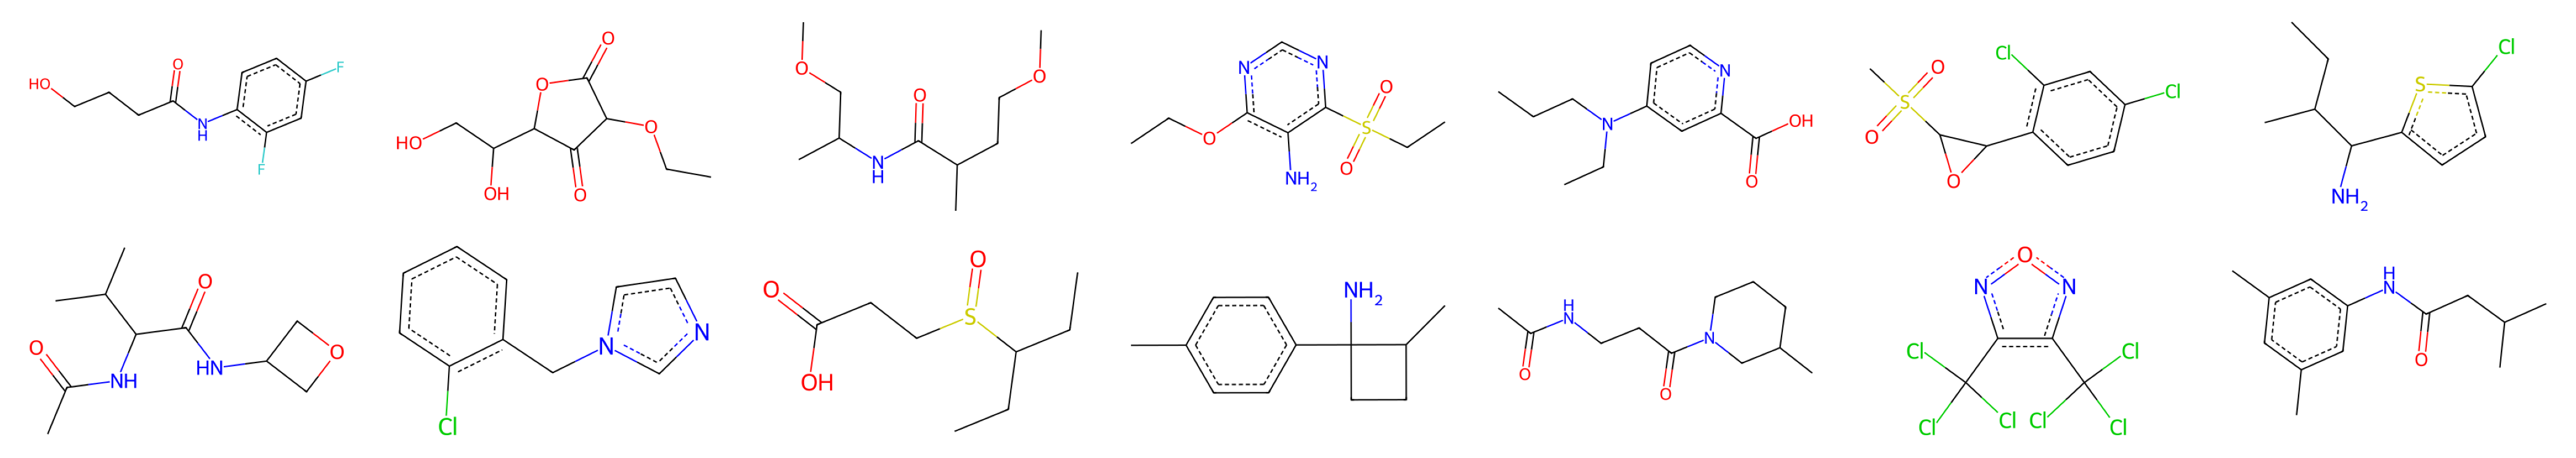

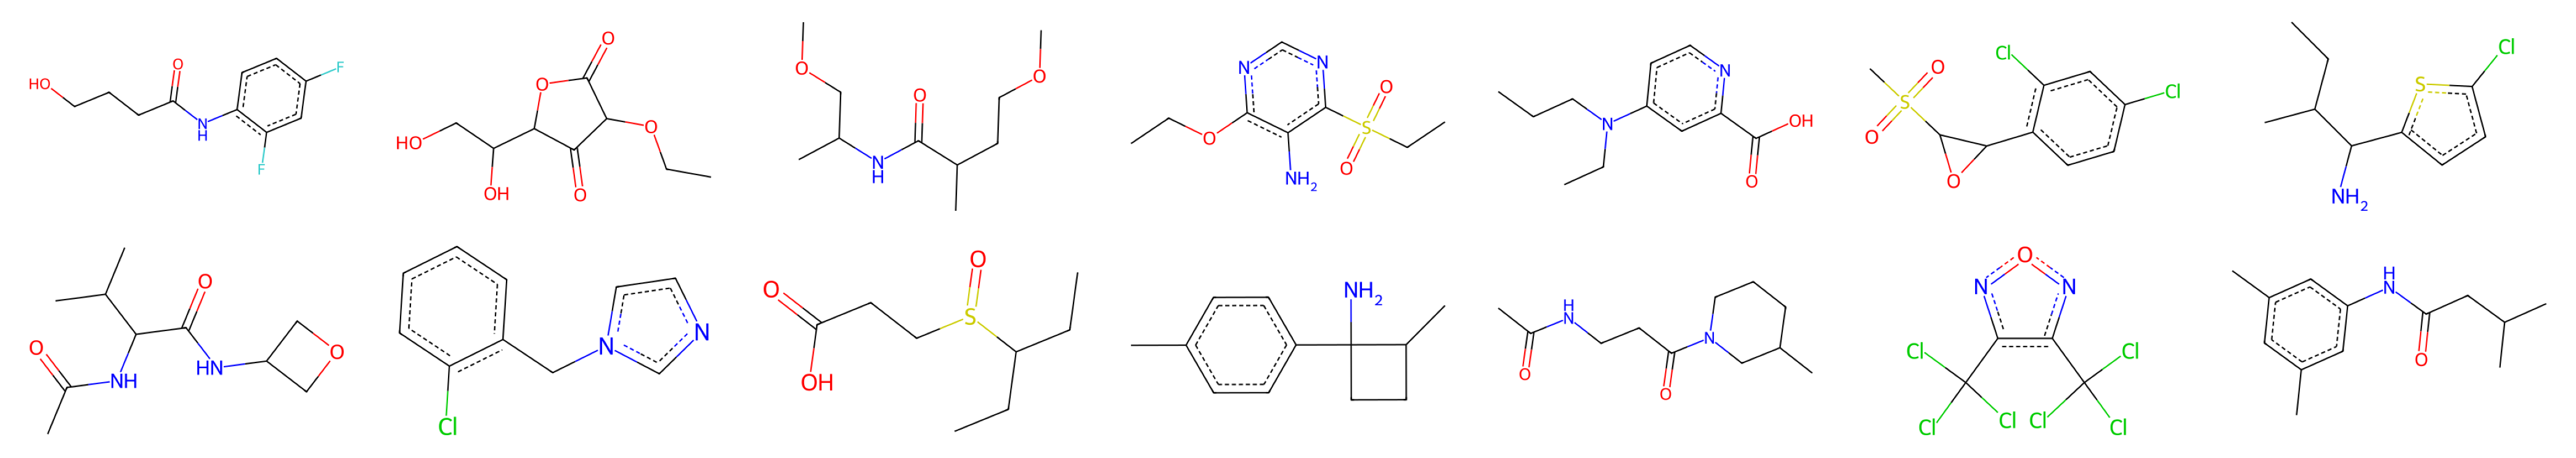

In [6]:
def draw_graphs(graphs, n=None, title=None, titles=None, n_graphs_per_line=7, **kwargs):
    graph_list = list(graphs)
    if n is not None:
        graph_list = graph_list[:n]
    if not graph_list:
        print('No graphs to display.')
        return None
    if title:
        print(title)
    legends = titles or kwargs.pop('legends', None)
    plot_kwargs = {**REPAIR_ARTIFICIAL_PLOT_KWARGS, **kwargs}
    if REPAIR_GRAPH_RENDERER is not None:
        return REPAIR_GRAPH_RENDERER(
            graph_list,
            titles=legends,
            n_graphs_per_line=n_graphs_per_line,
        )
    return plot_networkx_graphs(
        graph_list,
        n_cols=max(1, min(n_graphs_per_line, len(graph_list))),
        titles=legends,
        **plot_kwargs,
    )


def load_repair_graph_dataset(source):
    source = source.lower().strip()
    if source == 'zinc':
        csv_path = download_zinc_dataset(REPAIR_ZINC_DATA_ROOT, filename=REPAIR_ZINC_FILENAME)
        print(f'Repair ZINC CSV: {csv_path}')
        graphs = list(
            iter_selected_source_graphs(
                csv_path,
                'zinc_csv',
                limit=REPAIR_ZINC_LIMIT,
                random_state=RANDOM_SEED,
                max_selected=REPAIR_DATASET_SIZE,
            )
        )
        try:
            from abstractgraph_graphicalizer.chem import draw_molecules
        except ModuleNotFoundError:
            renderer = DECODER_GRAPH_RENDERER
        else:
            renderer = DECODER_GRAPH_RENDERER or draw_molecules
        return graphs, renderer

    if source == 'artificial':
        if REPAIR_ARTIFICIAL_CONFIG_FILE is not None:
            graphs, _plot_artificial_graphs = generate_artificial_dataset(
                load_from_file=REPAIR_ARTIFICIAL_CONFIG_FILE,
                save_config=False,
            )
        else:
            graphs, _plot_artificial_graphs = generate_artificial_dataset(
                num_graphs=REPAIR_DATASET_SIZE,
                seed=RANDOM_SEED,
                save_config=False,
                **REPAIR_ARTIFICIAL_CONFIG,
            )
        return graphs, DECODER_GRAPH_RENDERER

    raise ValueError(
        "REPAIR_DATASET_SOURCE must be 'artificial' or 'zinc' "
        f'(got {REPAIR_DATASET_SOURCE!r}).'
    )


repair_graph_dataset, REPAIR_GRAPH_RENDERER = load_repair_graph_dataset(REPAIR_DATASET_SOURCE)

print(f'Loaded {len(repair_graph_dataset)} repair graphs from {REPAIR_DATASET_SOURCE!r}.')
print('Repair node counts:', sorted({graph.number_of_nodes() for graph in repair_graph_dataset}))
draw_graphs(repair_graph_dataset, n=14, title='Repair dataset preview')



In [ ]:
N_SAMPLES = 1
sample_variants = graph_generator.sample(
    n_samples=N_SAMPLES,
    return_decode_stages=True,
)
raw_samples = [graph for graph in sample_variants['raw'] if graph is not None]

for variant_key, title_prefix in (
    ('raw', 'Raw'),
    ('ilp', 'ILP'),
    ('oracle', 'Oracle ILP'),
):
    variant_samples = [
        graph for graph in sample_variants[variant_key] if graph is not None
    ]
    if not variant_samples:
        print(f'No {title_prefix.lower()} samples to display.')
        continue
    feasibility_estimator = graph_generator.feasibility_estimator
    if feasibility_estimator is None:
        feasible_mask = None
        feasibility_summary = 'feasibility estimator unavailable'
        graph_titles = [
            f'{title_prefix} {idx} | feasible: unknown'
            for idx in range(len(variant_samples))
        ]
    else:
        feasible_mask = np.asarray(
            feasibility_estimator.predict(variant_samples),
            dtype=bool,
        )
        feasibility_summary = (
            f'feasible: {int(feasible_mask.sum())}/{len(feasible_mask)}'
        )
        graph_titles = [
            f"{title_prefix} {idx} | feasible: {'yes' if is_feasible else 'no'}"
            for idx, is_feasible in enumerate(feasible_mask)
        ]
    print(f'{title_prefix}: {feasibility_summary}')
    draw_graphs(
        variant_samples,
        n=len(variant_samples),
        title=f'{title_prefix} generation samples | {feasibility_summary}',
        titles=graph_titles,
        n_graphs_per_line=N_SAMPLES,
    )


In [ ]:
repair_results = repair_candidate_graphs(
    variant_samples,
    n_neighbors=7*3,
    graph_generator=graph_generator,
    repair_graph_dataset=repair_graph_dataset,
    random_seed=RANDOM_SEED,
    store_per_size=REPAIR_STORE_PER_SIZE,
    draw_graphs_fn=draw_graphs,
    edge_label_values=REPAIR_EDGE_LABEL_VALUES,
)


In [ ]:
if graph_generator.feasibility_estimator is None:
    raise RuntimeError('Feasibility estimator is unavailable in this environment.')

graph_generator.feasibility_rejection_mode = "fallback_unfiltered" #"fallback_unfiltered"  or "strict"

filtered_samples = graph_generator.sample(
    n_samples=N_SAMPLES,
    apply_feasibility_filtering=True,
)
draw_graphs(filtered_samples, n=N_SAMPLES, title='Generation samples with feasibility filtering')



In [ ]:
repair_results = repair_candidate_graphs(
    filtered_samples,
    n_neighbors=7*1,
    graph_generator=graph_generator,
    repair_graph_dataset=repair_graph_dataset,
    random_seed=RANDOM_SEED,
    store_per_size=REPAIR_STORE_PER_SIZE,
    draw_graphs_fn=draw_graphs,
    edge_label_values=REPAIR_EDGE_LABEL_VALUES,
)
